# Samsung Global Sales Dataset - Comprehensive Analysis

**Goal:** Explore and analyze the Samsung Global Sales Dataset to uncover interesting trends, analyze customer behavior, and visualize revenue drivers.

## Table of Contents
1. Data Loading & Initial Inspection
2. Data Cleaning & Preprocessing
3. Exploratory Data Analysis (EDA)
   - 3.1 Overall Sales & Revenue Trend
   - 3.2 Category & Product Performance
   - 3.3 Geographical Insights
   - 3.4 Customer Demographics & Behavior
   - 3.5 The Impact of 5G
4. Conclusion & Key Takeaways


In [1]:
## Import essential libraries for data analysis and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os


## Set plotting style and ignore warnings for cleaner output
sns.set_theme(style="whitegrid")
warnings.filterwarnings('ignore')



## 1. Data Loading & Initial Inspection

In [2]:


## Load the dataset
file_path = '/kaggle/input/datasets/ashyou09/samsung-global-product-sales-dataset/samsung_global_sales_dataset.csv'
df = pd.read_csv(file_path)

## Display the first few rows
display(df.head())

## General information about the dataset (columns, data types, nulls)
display(df.info())


,sale_id,sale_date,year,quarter,month,country,region,city,product_name,category,...,currency,fx_rate_to_usd,revenue_local_currency,sales_channel,payment_method,customer_segment,customer_age_group,previous_device_os,customer_rating,return_status
0,SAMS-00000001,2021-01-01,2021,Q1,January,Argentina,South America,Buenos Aires,Samsung Galaxy Tab S9 Ultra,Galaxy Tab,...,ARS,907.0,1130820.39,E-commerce Platform,Samsung Pay,Business,45–54,NaN,3.2,Kept
1,SAMS-00000002,2021-03-23,2021,Q1,March,Argentina,South America,Buenos Aires,Samsung Galaxy S23,Galaxy S,...,ARS,907.0,1322152.04,Authorized Reseller,Net Banking,Government,55+,Feature Phone,NaN,Kept
2,SAMS-00000003,2021-05-22,2021,Q2,May,Argentina,South America,Buenos Aires,Samsung Galaxy A34 5G,Galaxy A,...,ARS,907.0,1964398.74,Corporate / B2B,Gift Card,Individual,25–34,New User,3.5,Kept
3,SAMS-00000004,2021-07-26,2021,Q3,July,Argentina,South America,Buenos Aires,Samsung T55 27-inch FHD,Monitor,...,ARS,907.0,660359.49,Third-Party Retailer,BNPL (Buy Now Pay Later),Enterprise,55+,NaN,4.0,Kept
4,SAMS-00000005,2021-09-02,2021,Q3,September,Argentina,South America,Buenos Aires,Samsung Galaxy Z Fold 4,Galaxy Z,...,ARS,907.0,2835245.72,Authorized Reseller,Gift Card,Business,55+,Android (Other),3.0,Kept


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15500 entries, 0 to 15499
Data columns (total 28 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   sale_id                 15500 non-null  object 
 1   sale_date               15500 non-null  object 
 2   year                    15500 non-null  int64  
 3   quarter                 15500 non-null  object 
 4   month                   15500 non-null  object 
 5   country                 15500 non-null  object 
 6   region                  15500 non-null  object 
 7   city                    15500 non-null  object 
 8   product_name            15500 non-null  object 
 9   category                15500 non-null  object 
 10  storage                 7651 non-null   object 
 11  color                   15500 non-null  object 
 12  is_5g                   15500 non-null  object 
 13  unit_price_usd          15500 non-null  float64
 14  discount_pct            15500 non-null

None

## 2. Data Cleaning & Preprocessing

In [3]:
## Check for missing values
missing_values = df.isnull().sum()
display(missing_values[missing_values > 0])

## Convert sale_date from object/string to datetime format
df['sale_date'] = pd.to_datetime(df['sale_date'])

## Fill missing values where appropriate

if 'customer_rating' in df.columns:
    df['customer_rating'].fillna(df['customer_rating'].median(), inplace=True)

## Extract Year-Month for time-series analysis
df['year_month'] = df['sale_date'].dt.to_period('M')

## Verify changes
display(df.describe())


storage               7849
previous_device_os    9373
customer_rating       4251
dtype: int64

,sale_date,year,unit_price_usd,discount_pct,units_sold,discounted_price_usd,revenue_usd,fx_rate_to_usd,revenue_local_currency,customer_rating
count,15500,15500.000000,15500.000000,15500.000000,15500.000000,15500.000000,15500.000000,15500.000000,1.550000e+04,15500.000000
mean,2023-01-04 11:56:33.754838784,2022.511935,665.116825,5.708452,2.360000,627.134001,1478.145734,1054.528710,1.595853e+06,3.731581
min,2021-01-01 00:00:00,2021.000000,8.200000,0.000000,1.000000,6.600000,6.610000,0.790000,6.080000e+00,2.500000
25%,2022-01-12 00:00:00,2022.000000,185.435000,0.000000,1.000000,172.780000,254.265000,1.360000,1.199072e+03,3.400000
50%,2023-01-04 00:00:00,2023.000000,421.490000,3.000000,2.000000,397.410000,739.380000,10.650000,7.813940e+03,3.700000
75%,2024-01-05 00:00:00,2024.000000,938.657500,10.000000,3.000000,882.907500,1695.315000,110.000000,9.126992e+04,4.100000
max,2024-12-31 00:00:00,2024.000000,5442.700000,20.000000,10.000000,5442.700000,47665.900000,24500.000000,3.647727e+08,5.000000
std,NaN,1.113496,736.014360,6.406814,1.897958,695.723305,2368.688098,4062.232887,1.092157e+07,0.614742


## 3. Exploratory Data Analysis (EDA)
### 3.1 Overall Sales & Revenue Trend
Let's see how Samsung's revenue has evolved over time.

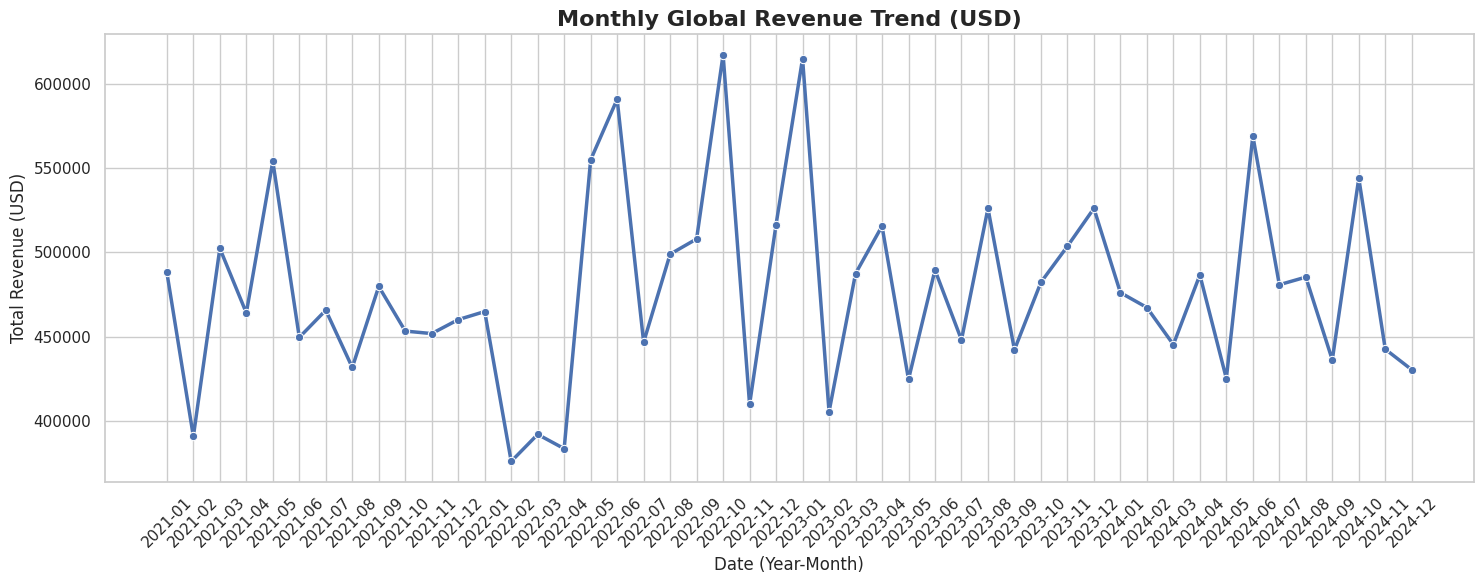

In [4]:
## Group by month using our Year-Month column
monthly_revenue = df.groupby('year_month')['revenue_usd'].sum().reset_index()
monthly_revenue['year_month'] = monthly_revenue['year_month'].astype(str)

plt.figure(figsize=(15, 6))
sns.lineplot(data=monthly_revenue, x='year_month', y='revenue_usd', marker='o', color='b', linewidth=2.5)
plt.title('Monthly Global Revenue Trend (USD)', fontsize=16, fontweight='bold')
plt.xlabel('Date (Year-Month)', fontsize=12)
plt.ylabel('Total Revenue (USD)', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### 3.2 Category & Product Performance
Which product categories contribute the most to Samsung's revenue?

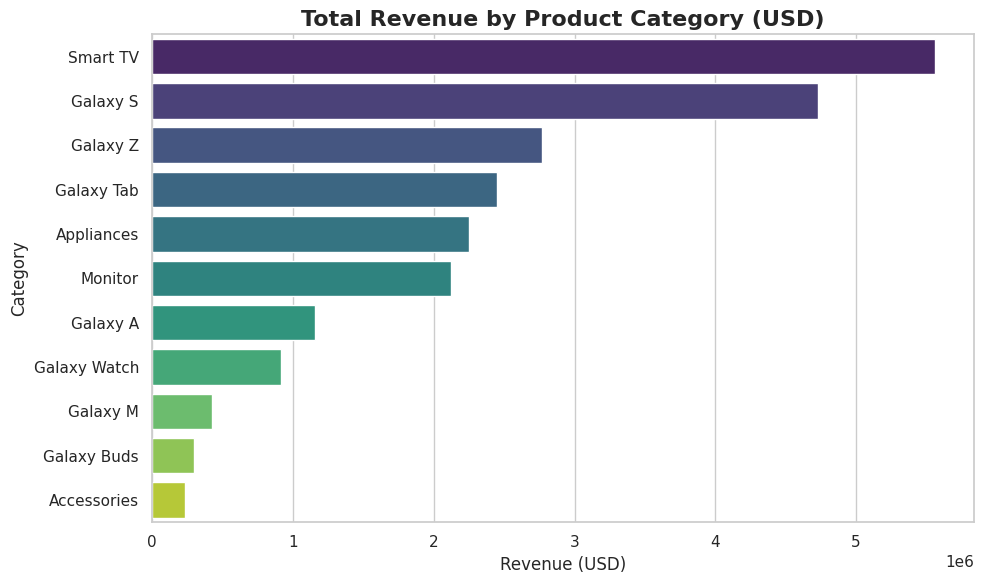

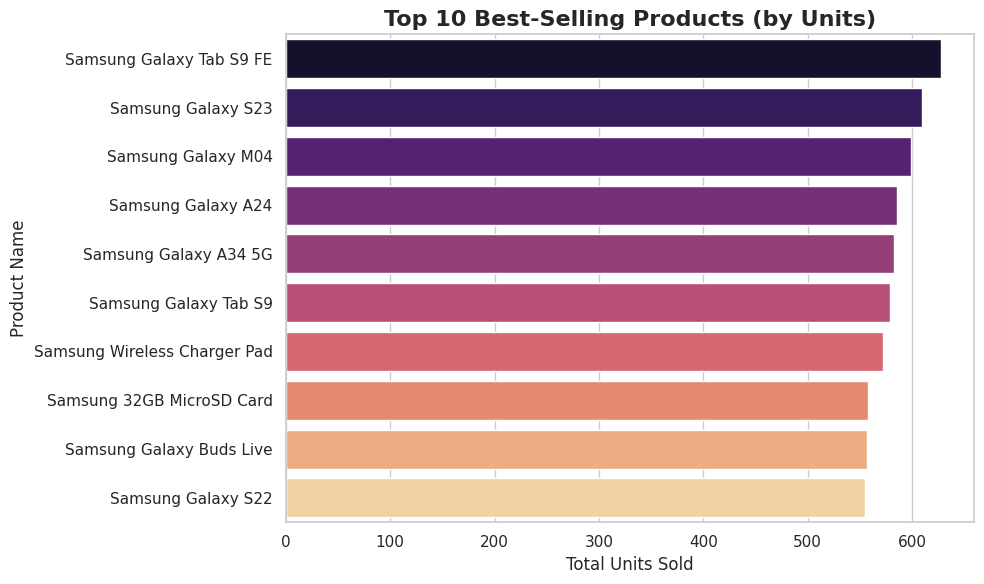

In [5]:
## Group by product category
category_revenue = df.groupby('category')['revenue_usd'].sum().sort_values(ascending=False).reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(data=category_revenue, x='revenue_usd', y='category', palette='viridis')
plt.title('Total Revenue by Product Category (USD)', fontsize=16, fontweight='bold')
plt.xlabel('Revenue (USD)', fontsize=12)
plt.ylabel('Category', fontsize=12)
plt.tight_layout()
plt.show()

## Look at the top 10 best-selling specific products by units sold
top_products = df.groupby('product_name')['units_sold'].sum().sort_values(ascending=False).head(10).reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(data=top_products, x='units_sold', y='product_name', palette='magma')
plt.title('Top 10 Best-Selling Products (by Units)', fontsize=16, fontweight='bold')
plt.xlabel('Total Units Sold', fontsize=12)
plt.ylabel('Product Name', fontsize=12)
plt.tight_layout()
plt.show()


### 3.3 Geographical Insights
Hou does performance vary across different regions?

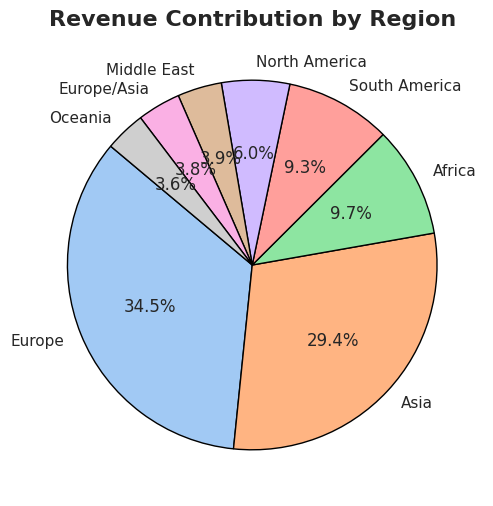

In [6]:
## Revenue by Region
region_revenue = df.groupby('region')['revenue_usd'].sum().sort_values(ascending=False).reset_index()

plt.figure(figsize=(10, 6))
plt.pie(region_revenue['revenue_usd'], labels=region_revenue['region'], autopct='%1.1f%%', 
        startangle=140, colors=sns.color_palette('pastel'), wedgeprops={'edgecolor': 'black'})
plt.title('Revenue Contribution by Region', fontsize=16, fontweight='bold')
plt.show()


### 3.4 Customer Demographics & Behavior
Who is buying Samsung products?

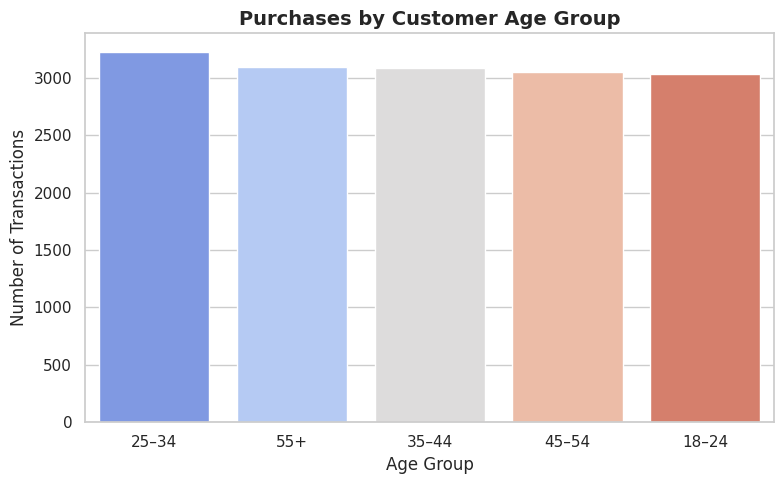

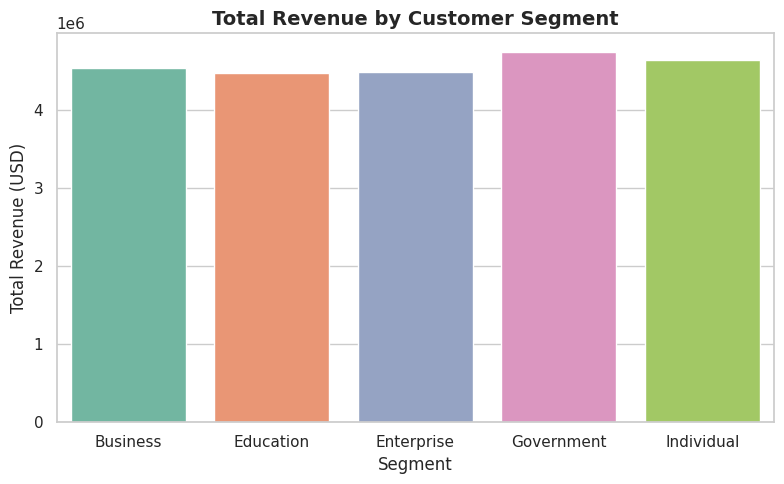

In [7]:
## Customer Age Group Distribution
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='customer_age_group', order=df['customer_age_group'].value_counts().index, palette='coolwarm')
plt.title('Purchases by Customer Age Group', fontsize=14, fontweight='bold')
plt.xlabel('Age Group', fontsize=12)
plt.ylabel('Number of Transactions', fontsize=12)
plt.tight_layout()
plt.show()

## Impact of Customer Segment on Revenue
segment_revenue = df.groupby('customer_segment')['revenue_usd'].sum().reset_index()

plt.figure(figsize=(8, 5))
sns.barplot(data=segment_revenue, x='customer_segment', y='revenue_usd', palette='Set2')
plt.title('Total Revenue by Customer Segment', fontsize=14, fontweight='bold')
plt.xlabel('Segment', fontsize=12)
plt.ylabel('Total Revenue (USD)', fontsize=12)
plt.tight_layout()
plt.show()


### 3.5 The Impact of 5G Connectivity
For smartphones (Galaxy S, Z, A, M), what is the preference for 5G vs Non-5G?

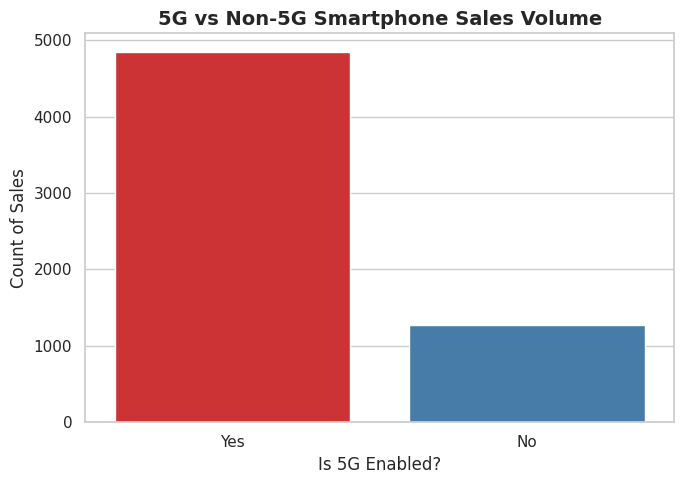

In [8]:
## Filter for smartphone categories roughly
smartphones = df[df['category'].isin(['Galaxy S', 'Galaxy Z', 'Galaxy A', 'Galaxy M'])]

if not smartphones.empty and 'is_5g' in smartphones.columns:
    plt.figure(figsize=(7, 5))
    sns.countplot(data=smartphones, x='is_5g', palette='Set1')
    plt.title('5G vs Non-5G Smartphone Sales Volume', fontsize=14, fontweight='bold')
    plt.xlabel('Is 5G Enabled?', fontsize=12)
    plt.ylabel('Count of Sales', fontsize=12)
    plt.tight_layout()
    plt.show()


## 4. Conclusion & Key Takeaways
Based on our exploratory data analysis, we can summarize the following crucial points:
- **Trend:** There are clear seasonal spikes in monthly revenue, likely tying into global product launch cycles (e.g., Unpacked events) or holiday sales.
- **Top Categories:** Certain flagship or high-end series (such as Galaxy S or Smart TVs) drive the bulk of the overall USD revenue, though accessories might sell more bare units.
- **Demographics & Geography:** Specific regions dominate the sales pie, and understanding the core age group provides marketing insights for targeted advertising.
- **Technology Adoption:** There is a notable trend towards 5G-enabled devices among the smartphone categories as technology matures.

*This notebook demonstrates a structured approach to business data analytics using Python.*
